# Kidney Transplant SISA Unlearning

This notebook implements **Sharded, Isolated, Sliced and Aggregated (SISA)** training for the synthetic longitudinal kidney-transplant assessments. The forward-looking target is acute rejection during the 30 days after an assessment—not kidney failure. Complete six-assessment recipient episodes and linked donor data stay in one shard.

SISA must be organised before deletion requests: isolation limits retraining to affected shards, slices provide rollback points, and shard probabilities are averaged. We report a common monolithic full-retraining comparison separately from an exact method-matched clean SISA comparison. Behavioural similarity is not proof of complete internal deletion, and this research system is not clinically validated.

## 2. Imports, Configuration and Paths

This setup reloads immutable baseline and deletion artifacts. Creating all directories first avoids hidden dependence on an interactive session or pre-existing folders.

In [1]:
from __future__ import annotations

import copy
import hashlib
import json
import platform
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import torch
from IPython.display import Markdown, display
from scipy.stats import ks_2samp
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             brier_score_loss, confusion_matrix, f1_score, log_loss,
                             precision_score, recall_score, roc_auc_score)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
RANDOM_SEED = 42
SHARD_COUNT = 5
SLICE_COUNT = 5
EPOCHS_PER_STAGE = 3
BATCH_SIZE = 128
LEARNING_RATE = 0.001
EPSILON = 1e-7
THRESHOLD_GRID = np.round(np.arange(0.01, 1.00, 0.01), 2)
MINIMUM_OPERATIONAL_RECALL = 0.60
BOOTSTRAP_REPETITIONS = 500
BOOTSTRAP_SEED = 2026
MEMBERSHIP_REPETITIONS = 20
MEMBERSHIP_SEED = 3030

# The shard and slice layout is fixed before any deletion request exists.
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"SISA configuration: {SHARD_COUNT} shards × {SLICE_COUNT} slices | device: {DEVICE}")

SISA configuration: 5 shards × 5 slices | device: mps


In [3]:
def locate_code_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        direct = candidate / "data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
        nested = candidate / "code/data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
        if direct.is_file(): return candidate
        if nested.is_file(): return candidate / "code"
    raise FileNotFoundError("Could not locate processed KidneyTransplant data.")

def sha256(path: Path) -> str: return hashlib.sha256(path.read_bytes()).hexdigest()
def index_hash(values): return hashlib.sha256(np.asarray(values, dtype=np.int64).tobytes()).hexdigest()

CODE_ROOT = locate_code_root(Path.cwd().resolve())
DATA_PATH = CODE_ROOT / "data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
BASELINE_RESULTS = CODE_ROOT / "results/KidneyTransplant/baseline"
BASELINE_MODEL_PATH = CODE_ROOT / "models/KidneyTransplant/baseline/kidney_transplant_baseline_mlp.pt"
BASELINE_PREPROCESSOR_PATH = CODE_ROOT / "models/KidneyTransplant/baseline/kidney_transplant_preprocessor.joblib"
FULL_RESULTS = CODE_ROOT / "results/KidneyTransplant/full_retraining"
FULL_MODELS = CODE_ROOT / "models/KidneyTransplant/full_retraining"
RESULTS_ROOT = CODE_ROOT / "results/KidneyTransplant/sisa"
MODEL_ROOT = CODE_ROOT / "models/KidneyTransplant/sisa"

In [4]:
OUTPUT_DIRS = {name: RESULTS_ROOT / name for name in
               ["configuration", "histories", "metrics", "tables", "figures", "checkpoints"]}
# Create every destination before training to avoid reliance on stale folders.
for directory in [MODEL_ROOT, *OUTPUT_DIRS.values()]: directory.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame([
    {"artifact": "baseline inputs", "path": BASELINE_MODEL_PATH.parent.relative_to(CODE_ROOT)},
    {"artifact": "SISA models", "path": MODEL_ROOT.relative_to(CODE_ROOT)},
    {"artifact": "SISA results", "path": RESULTS_ROOT.relative_to(CODE_ROOT)},
]).style.hide(axis="index"))

artifact,path
baseline inputs,models/KidneyTransplant/baseline
SISA models,models/KidneyTransplant/sisa
SISA results,results/KidneyTransplant/sisa


## 3. Reload and Verify Upstream State

Saved row indices and hashes preserve the same training population and deletion requests used by every method.

In [5]:
baseline_manifest = json.loads((BASELINE_RESULTS / "configuration/baseline_manifest.json").read_text())
full_manifest = json.loads((FULL_RESULTS / "configuration/full_retraining_manifest.json").read_text())
baseline_checkpoint = torch.load(BASELINE_MODEL_PATH, map_location="cpu", weights_only=False)
baseline_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)
clean_df = pd.read_csv(DATA_PATH)

FEATURE_COLUMNS = baseline_checkpoint["feature_columns"]
EXCLUDED_COLUMNS = baseline_checkpoint["excluded_audit_columns"]
TARGET_COLUMN = baseline_checkpoint["target_column"]
THRESHOLD = float(baseline_checkpoint["fixed_baseline_validation_threshold"])
ARCHITECTURE = baseline_checkpoint["architecture"]
SCENARIOS = full_manifest["deletion_configuration"]
SCENARIO_NAMES = list(SCENARIOS)

assert sha256(DATA_PATH) == baseline_manifest["processed_dataset_hash"] == full_manifest["dataset_hash"]
assert THRESHOLD == full_manifest["threshold"]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.9.0 when using version 1.8.0. This might lead to breaking cod

In [6]:
split_indices = {name: np.load(CODE_ROOT / item["index_path"], allow_pickle=False)
                 for name, item in baseline_manifest["split_artifacts"].items()}
# Saved baseline positions preserve the original recipient-grouped experiment.
train_indices, validation_indices, test_indices = (split_indices[name] for name in ["train", "validation", "test"])
forget_indices = {name: np.load(FULL_RESULTS / f"indices/{name}_forget_indices.npy", allow_pickle=False)
                  for name in SCENARIO_NAMES}
retain_indices = {name: np.load(FULL_RESULTS / f"indices/{name}_retain_indices.npy", allow_pickle=False)
                  for name in SCENARIO_NAMES}
for name in SCENARIO_NAMES:
    assert set(forget_indices[name]).isdisjoint(retain_indices[name])
    assert set(forget_indices[name]) | set(retain_indices[name]) == set(train_indices)
    assert index_hash(forget_indices[name]) == full_manifest["index_hashes"][name]["forget"]

In [7]:
features = clean_df[FEATURE_COLUMNS]
target = clean_df[TARGET_COLUMN].astype(int)
metadata = clean_df[["recipient_id", "donor_id", "hospital_id", "training_consent_version",
                     "assessment_date", "days_since_transplant", "donor_type"]].copy()
metadata["assessment_date"] = pd.to_datetime(metadata["assessment_date"], errors="raise")
metadata["derived_transplant_date"] = metadata["assessment_date"] - pd.to_timedelta(metadata["days_since_transplant"], unit="D")

def related_mask(frame, name):
    # Entity IDs cannot cross splits, but provider and cohort rules can match holdouts.
    if name == "s3_hospital_withdrawal": return frame["hospital_id"].eq("H07")
    if name == "s4_invalid_consent": return frame["training_consent_version"].eq("RECIPIENT_V3")
    if name == "s5_retention_expiry":
        cutoff = metadata.loc[forget_indices[name], "derived_transplant_date"].max()
        return frame["derived_transplant_date"].le(cutoff)
    return pd.Series(False, index=frame.index)

## 4. Recipient-Grouped Shards and Ordered Slices

Assignment happens at recipient level so no longitudinal or donor-linked episode crosses shards. Slices are fixed before any deletion request.

In [8]:
training_recipients = np.sort(metadata.loc[train_indices, "recipient_id"].unique())
shuffled_recipients = np.random.default_rng(RANDOM_SEED).permutation(training_recipients)
recipient_shards = np.array_split(shuffled_recipients, SHARD_COUNT)

SHARD_SLICES = {}
assignment_rows = []
for shard_id, shard_recipients in enumerate(recipient_shards):
    # The shuffled order is frozen; consecutive blocks define deterministic replay stages.
    recipient_slices = np.array_split(shard_recipients, SLICE_COUNT)
    SHARD_SLICES[shard_id] = []
    for slice_id, recipients in enumerate(recipient_slices, start=1):
        rows = metadata.loc[train_indices].index[metadata.loc[train_indices, "recipient_id"].isin(recipients)].to_numpy(np.int64)
        SHARD_SLICES[shard_id].append(rows)
        assignment_rows.append({"shard": shard_id, "slice": slice_id,
                                "recipients": len(recipients), "rows": len(rows)})
assignment = pd.DataFrame(assignment_rows)
display(assignment.style.hide(axis="index"))

shard,slice,recipients,rows
0,1,280,1680
0,2,280,1680
0,3,280,1680
0,4,280,1680
0,5,280,1680
1,1,280,1680
1,2,280,1680
1,3,280,1680
1,4,280,1680
1,5,280,1680


In [9]:
# Verify every recipient and donor appears in exactly one shard.
row_to_shard = {}
for shard_id, slices in SHARD_SLICES.items():
    for row in np.concatenate(slices): row_to_shard[int(row)] = shard_id
assert set(row_to_shard) == set(train_indices)
recipient_shard_counts = metadata.loc[train_indices].assign(
    shard=[row_to_shard[int(i)] for i in train_indices]
).groupby("recipient_id")["shard"].nunique()
donor_shard_counts = metadata.loc[train_indices].assign(
    shard=[row_to_shard[int(i)] for i in train_indices]
).groupby("donor_id")["shard"].nunique()
assert recipient_shard_counts.eq(1).all() and donor_shard_counts.eq(1).all()
assert assignment.groupby("shard")["rows"].sum().eq(8_400).all()
print("All 7,000 recipient episodes and linked donors are isolated within one shard.")

All 7,000 recipient episodes and linked donors are isolated within one shard.


## 5. SISA Model and Deterministic Stage Training

A checkpoint after slice k contains cumulative training through slices 1…k. Checkpoint 0 is the deterministic initial state before any rows are seen.

In [10]:
class KidneyMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__(); h1, h2 = ARCHITECTURE["hidden_layer_dimensions"]
        self.network = nn.Sequential(nn.Linear(input_dim, h1), nn.ReLU(),
                                     nn.Dropout(ARCHITECTURE["dropout_probability"]),
                                     nn.Linear(h1, h2), nn.ReLU(), nn.Linear(h2, 1))
    def forward(self, values): return self.network(values).squeeze(1)

def fresh_model(shard_id):
    # Isolated shard seeds make both clean training and replay deterministic.
    seed = RANDOM_SEED + shard_id
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    return KidneyMLP(baseline_checkpoint["input_dim"]).to(DEVICE)

def clone_state(model):
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

def predict_model(model, preprocessor, raw_features):
    processed = preprocessor.transform(raw_features).astype(np.float32); model.eval()
    with torch.no_grad(): logits = model(torch.tensor(processed, device=DEVICE))
    return torch.sigmoid(logits).cpu().numpy()

def ensemble_predict(models, raw_features):
    # Equal probability averaging is the predefined SISA aggregation rule.
    return np.mean([predict_model(models[shard], baseline_preprocessor, raw_features)
                    for shard in range(SHARD_COUNT)], axis=0)

In [11]:
def train_stage(model, row_indices, shard_id, slice_id):
    # Each stage sees only its current slice; earlier slices are represented by inherited weights.
    processed = baseline_preprocessor.transform(features.loc[row_indices]).astype(np.float32)
    dataset = TensorDataset(torch.tensor(processed), torch.tensor(target.loc[row_indices].to_numpy(), dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        generator=torch.Generator().manual_seed(RANDOM_SEED + 100*shard_id + slice_id))
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                                 weight_decay=baseline_checkpoint["training_configuration"]["weight_decay"])
    criterion = nn.BCEWithLogitsLoss(); loss_sum = 0.0; rows = 0
    model.train()
    for _ in range(EPOCHS_PER_STAGE):
        for batch_x, batch_y in loader:
            optimizer.zero_grad(); loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            loss.backward(); optimizer.step(); loss_sum += loss.item()*len(batch_y); rows += len(batch_y)
    return loss_sum / rows

def train_ensemble(excluded_rows=None):
    # Clean references use this identical procedure with forget rows removed from every stage.
    excluded = set() if excluded_rows is None else set(np.asarray(excluded_rows).tolist())
    models, checkpoints, histories = {}, {}, []
    started = time.perf_counter()
    for shard_id in range(SHARD_COUNT):
        model = fresh_model(shard_id); checkpoints[shard_id] = {0: clone_state(model)}
        for slice_id, slice_rows in enumerate(SHARD_SLICES[shard_id], start=1):
            retained_slice = np.asarray([int(row) for row in slice_rows if int(row) not in excluded], dtype=np.int64)
            loss = train_stage(model, retained_slice, shard_id, slice_id)
            checkpoints[shard_id][slice_id] = clone_state(model)
            histories.append({"shard": shard_id, "slice": slice_id, "slice_rows": len(retained_slice),
                              "actual_row_visits": len(retained_slice)*EPOCHS_PER_STAGE, "training_bce": loss})
        models[shard_id] = model
    return models, checkpoints, pd.DataFrame(histories), time.perf_counter()-started

## 6. Initial SISA Training

Initial cost is paid before deletion requests. Checkpoint 0 is deterministic initialization; checkpoint k follows training on slice k only, with inherited weights from earlier slices. A fresh optimiser is intentionally initialized for every slice as part of the frozen procedure.

In [12]:
initial_models, initial_checkpoints, initial_history, initial_runtime = train_ensemble()
# Initial training is an up-front lifecycle cost, not a deletion-request cost.
display(initial_history.style.hide(axis="index").format(precision=5))
print(f"Initial SISA training runtime: {initial_runtime:.2f} seconds")

shard,slice,slice_rows,actual_row_visits,training_bce
0,1,1680,5040,0.49808
0,2,1680,5040,0.22950
0,3,1680,5040,0.14122
0,4,1680,5040,0.07510
0,5,1680,5040,0.10421
1,1,1680,5040,0.53077
1,2,1680,5040,0.22249
1,3,1680,5040,0.12550
1,4,1680,5040,0.15795
1,5,1680,5040,0.12942


Initial SISA training runtime: 5.68 seconds


### 6.1 Frozen SISA Operating Threshold

Because the initial SISA ensemble is separately trained, its operational threshold is selected from initial-SISA validation predictions. The same recall-at-least-0.60 rule is frozen before evaluating any deletion request.

In [13]:
def select_operational_threshold(labels, probabilities):
    rows = []
    for threshold in THRESHOLD_GRID:
        predictions = probabilities >= threshold
        matrix = confusion_matrix(labels, predictions, labels=[0,1]); tn, fp, fn, tp = matrix.ravel()
        rows.append({"threshold": threshold, "precision": precision_score(labels,predictions,zero_division=0),
                     "recall": recall_score(labels,predictions,zero_division=0),
                     "f1": f1_score(labels,predictions,zero_division=0), "specificity": tn/(tn+fp),
                     "balanced_accuracy": balanced_accuracy_score(labels,predictions),
                     "predicted_positive_count": int(predictions.sum())})
    sweep = pd.DataFrame(rows); eligible = sweep.loc[sweep["recall"].ge(MINIMUM_OPERATIONAL_RECALL)]
    if len(eligible):
        selected = eligible.sort_values(["precision","f1","threshold"],ascending=False).iloc[0]
        reason = "highest precision with validation recall at least 0.60; F1 breaks precision ties"
    else:
        selected = sweep.sort_values(["recall","precision","f1","threshold"],ascending=False).iloc[0]
        reason = "fallback to maximum validation recall because no threshold reached 0.60"
    sweep["selected"] = sweep["threshold"].eq(selected["threshold"])
    return float(selected["threshold"]), sweep, reason

In [14]:
initial_sisa_validation_probabilities = ensemble_predict(initial_models, features.loc[validation_indices])
SISA_THRESHOLD, sisa_threshold_sweep, SISA_THRESHOLD_REASON = select_operational_threshold(
    target.loc[validation_indices], initial_sisa_validation_probabilities)
display(sisa_threshold_sweep[["threshold","precision","recall","f1","specificity","balanced_accuracy",
                              "predicted_positive_count","selected"]]
        .style.hide(axis="index").format(precision=4))
print(f"Frozen SISA validation threshold: {SISA_THRESHOLD:.2f} — {SISA_THRESHOLD_REASON}")

threshold,precision,recall,f1,specificity,balanced_accuracy,predicted_positive_count,selected
0.0100,0.0405,0.9801,0.0779,0.3346,0.6573,6068,False
0.0200,0.0582,0.9402,0.1097,0.5638,0.7520,4052,False
0.0300,0.0759,0.8566,0.1394,0.7008,0.7787,2833,False
0.0400,0.0966,0.7769,0.1718,0.7915,0.7842,2019,False
0.0500,0.1127,0.6534,0.1923,0.8524,0.7529,1455,True
0.0600,0.1324,0.5418,0.2128,0.8982,0.7200,1027,False
0.0700,0.1555,0.4422,0.2301,0.9311,0.6867,714,False
0.0800,0.1700,0.3426,0.2272,0.9520,0.6473,506,False
0.0900,0.1856,0.2669,0.2190,0.9664,0.6167,361,False
0.1000,0.2110,0.1992,0.2049,0.9786,0.5889,237,False


Frozen SISA validation threshold: 0.05 — highest precision with validation recall at least 0.60; F1 breaks precision ties


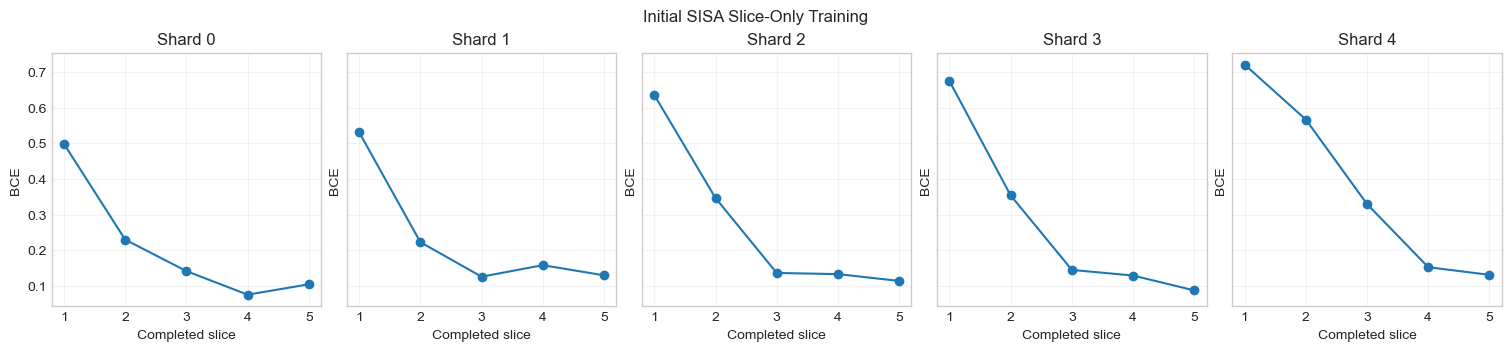

In [15]:
history_figure, history_axes = plt.subplots(1, 5, figsize=(15, 3.4), sharey=True, constrained_layout=True)
for shard_id, axis in enumerate(history_axes):
    rows = initial_history.query("shard == @shard_id")
    axis.plot(rows["slice"], rows["training_bce"], marker="o")
    axis.set(title=f"Shard {shard_id}", xlabel="Completed slice", ylabel="BCE")
    axis.grid(alpha=0.25)
history_figure.suptitle("Initial SISA Slice-Only Training")
display(history_figure); plt.close(history_figure)

## 7. Rollback and Selective Replay

For each affected shard, replay begins from the checkpoint immediately before its earliest affected slice. Unaffected shards reuse their original final model.

In [16]:
def affected_plan(forget_rows):
    # The earliest touched slice determines the rollback boundary for each shard.
    forgotten = set(np.asarray(forget_rows).tolist()); plan = {}
    for shard_id, slices in SHARD_SLICES.items():
        affected = [slice_id for slice_id, rows in enumerate(slices, start=1) if forgotten & set(rows.tolist())]
        if affected: plan[shard_id] = min(affected)
    return plan

def replay_scenario(name):
    forgotten = set(forget_indices[name].tolist()); plan = affected_plan(forget_indices[name])
    # Unaffected shards retain their original final state without replay.
    models = {shard: copy.deepcopy(model) for shard, model in initial_models.items()}
    history = []; started = time.perf_counter(); replay_row_visits = 0
    for shard_id, earliest in plan.items():
        model = fresh_model(shard_id); model.load_state_dict(initial_checkpoints[shard_id][earliest-1])
        for slice_id in range(earliest, SLICE_COUNT+1):
            retained_slice = np.asarray([int(row) for row in SHARD_SLICES[shard_id][slice_id-1]
                                         if int(row) not in forgotten], dtype=np.int64)
            loss = train_stage(model, retained_slice, shard_id, slice_id)
            replay_row_visits += len(retained_slice)*EPOCHS_PER_STAGE
            history.append({"scenario": name, "shard": shard_id, "slice": slice_id,
                            "slice_rows": len(retained_slice),
                            "actual_row_visits": len(retained_slice)*EPOCHS_PER_STAGE,
                            "training_bce": loss})
        models[shard_id] = model
    return models, pd.DataFrame(history), time.perf_counter()-started, plan, replay_row_visits

In [17]:
replay_runs = {}
for name in SCENARIO_NAMES:
    models, history, runtime, plan, row_visits = replay_scenario(name)
    replay_runs[name] = {"models": models, "history": history, "runtime_seconds": runtime,
                         "plan": plan, "replay_row_visits": row_visits}
    print(f"{name}: affected shards {plan}; replay {runtime:.2f} seconds")

s1_recipient_withdrawal: affected shards {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}; replay 6.73 seconds


s2_living_donor_withdrawal: affected shards {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}; replay 6.24 seconds


s3_hospital_withdrawal: affected shards {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}; replay 6.44 seconds


s4_invalid_consent: affected shards {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}; replay 4.47 seconds


s5_retention_expiry: affected shards {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}; replay 6.50 seconds


## 8. Clean Retain-Only SISA Model References

`clean_retain_only_sisa_model_reference` trains the same slice-only model procedure from deterministic initial states after removing the request. It deliberately retains the original frozen preprocessor, so exact equality tests model replay correctness rather than a completely clean pipeline.

In [18]:
clean_runs = {}
for name in SCENARIO_NAMES:
    models, checkpoints, history, runtime = train_ensemble(excluded_rows=forget_indices[name])
    clean_runs[name] = {"models": models, "checkpoints": checkpoints, "history": history,
                        "runtime_seconds": runtime}
    print(f"{name}: clean retain-only SISA model reference {runtime:.2f} seconds")

s1_recipient_withdrawal: clean retain-only SISA model reference 4.76 seconds


s2_living_donor_withdrawal: clean retain-only SISA model reference 4.54 seconds


s3_hospital_withdrawal: clean retain-only SISA model reference 4.35 seconds


s4_invalid_consent: clean retain-only SISA model reference 4.24 seconds


s5_retention_expiry: clean retain-only SISA model reference 4.28 seconds


## 9. Shared Prediction and Metric Definitions

All shard outputs receive equal probability weight. SISA operational metrics use its frozen validation threshold; monolithic models retain the monolithic frozen threshold. Threshold-independent PR-AUC and Brier score remain directly comparable.

In [19]:
def utility_metrics(labels, probabilities, operational_threshold):
    p = np.clip(np.asarray(probabilities, float), EPSILON, 1-EPSILON)
    predictions = p >= operational_threshold
    matrix = confusion_matrix(labels, predictions, labels=[0,1]); tn, fp, fn, tp = matrix.ravel()
    return {"auroc": roc_auc_score(labels,p), "pr_auc": average_precision_score(labels,p),
            "brier_score": brier_score_loss(labels,p), "bce": log_loss(labels,p,labels=[0,1]),
            "f1": f1_score(labels,predictions,zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(labels,predictions),
            "precision": precision_score(labels,predictions,zero_division=0),
            "recall": recall_score(labels,predictions,zero_division=0), "specificity": tn/(tn+fp),
            "tn":tn,"fp":fp,"fn":fn,"tp":tp}

In [20]:
def truth_ratio(labels, probabilities):
    # This binary classifier adaptation is inspired by, but is not, generative TOFU.
    y = labels.to_numpy(float); p = np.clip(np.asarray(probabilities,float), EPSILON,1-EPSILON)
    p_correct = np.clip(y*p + (1-y)*(1-p), EPSILON,1-EPSILON)
    return (1-p_correct)/p_correct

def forget_quality(labels, original, unlearned, reference, agreement_threshold):
    before = ks_2samp(truth_ratio(labels,original), truth_ratio(labels,reference))
    after = ks_2samp(truth_ratio(labels,unlearned), truth_ratio(labels,reference))
    before_mae=np.abs(original-reference).mean(); after_mae=np.abs(unlearned-reference).mean(); y=labels.to_numpy(float)
    confidence=lambda p:(y*p+(1-y)*(1-p)).mean()
    return {"ks_d_before":before.statistic,"ks_d_after":after.statistic,
            "ks_d_improvement":before.statistic-after.statistic,"ks_p_value_after":after.pvalue,
            "probability_mae_before":before_mae,"probability_mae_after":after_mae,
            "probability_mae_improvement":before_mae-after_mae,
            "prediction_agreement_after":((unlearned>=agreement_threshold)==(reference>=agreement_threshold)).mean(),
            "absolute_bce_difference_after":abs(log_loss(labels,np.clip(unlearned,EPSILON,1-EPSILON),labels=[0,1])-
                                                log_loss(labels,np.clip(reference,EPSILON,1-EPSILON),labels=[0,1])),
            "absolute_confidence_difference_after":abs(confidence(unlearned)-confidence(reference)),
            "forget_rows":len(labels)}

In [21]:
def class_conditional_quality(labels, original, unlearned, reference):
    rows=[]
    for subset,class_value in [("all",None),("target_0",0),("target_1",1)]:
        mask=np.ones(len(labels),bool) if class_value is None else labels.to_numpy()==class_value
        count=int(mask.sum())
        if count<20:
            rows.append({"subset":subset,"row_count":count,"ks_d_before":np.nan,"ks_d_after":np.nan,
                         "probability_mae_before":np.nan,"probability_mae_after":np.nan}); continue
        subset_labels=labels.iloc[np.flatnonzero(mask)]
        rows.append({"subset":subset,"row_count":count,
            "ks_d_before":ks_2samp(truth_ratio(subset_labels,original[mask]),truth_ratio(subset_labels,reference[mask])).statistic,
            "ks_d_after":ks_2samp(truth_ratio(subset_labels,unlearned[mask]),truth_ratio(subset_labels,reference[mask])).statistic,
            "probability_mae_before":np.abs(original[mask]-reference[mask]).mean(),
            "probability_mae_after":np.abs(unlearned[mask]-reference[mask]).mean()})
    return rows

def per_record_bce(labels,probabilities):
    y=np.asarray(labels,float); p=np.clip(np.asarray(probabilities,float),EPSILON,1-EPSILON)
    return -(y*np.log(p)+(1-y)*np.log(1-p))

In [22]:
def matched_nonmembers(name, nonmember_indices, repeat):
    forget_frame=metadata.loc[forget_indices[name]].assign(target=target.loc[forget_indices[name]].to_numpy())
    candidates=metadata.loc[nonmember_indices].assign(target=target.loc[nonmember_indices].to_numpy())
    rng=np.random.default_rng(MEMBERSHIP_SEED+100*SCENARIO_NAMES.index(name)+repeat); sampled=[]
    for keys,group in forget_frame.groupby(["target","days_since_transplant","donor_type"],dropna=False):
        pool=candidates.loc[candidates["target"].eq(keys[0]) &
                            candidates["days_since_transplant"].eq(keys[1]) &
                            candidates["donor_type"].eq(keys[2])]
        if pool.empty: pool=candidates.loc[candidates["target"].eq(keys[0]) & candidates["days_since_transplant"].eq(keys[1])]
        if pool.empty: pool=candidates.loc[candidates["target"].eq(keys[0])]
        sampled.extend(rng.choice(pool.index.to_numpy(),size=len(group),replace=len(pool)<len(group)))
    return np.asarray(sampled,np.int64)

def membership_summary(name, member_probabilities, predictors, nonmember_indices):
    member_y=target.loc[forget_indices[name]].to_numpy(); rows=[]
    member_scores={model:-per_record_bce(member_y,p) for model,p in member_probabilities.items()}
    for repeat in range(MEMBERSHIP_REPETITIONS):
        sampled=matched_nonmembers(name,nonmember_indices,repeat); nonmember_y=target.loc[sampled].to_numpy()
        attack_y=np.r_[np.ones(len(member_y)),np.zeros(len(nonmember_y))]
        for model,predictor in predictors.items():
            scores=np.r_[member_scores[model],-per_record_bce(nonmember_y,predictor(features.loc[sampled]))]
            rows.append({"model":model,"repeat":repeat,"attack_roc_auc":roc_auc_score(attack_y,scores)})
    return pd.DataFrame(rows).groupby("model")["attack_roc_auc"].agg(["mean","std"]).reset_index()

In [23]:
def recipient_mae_bootstrap(name,original,unlearned,reference):
    recipients=metadata.loc[forget_indices[name],"recipient_id"].to_numpy(); unique=np.unique(recipients)
    positions={recipient:np.flatnonzero(recipients==recipient) for recipient in unique}
    rng=np.random.default_rng(BOOTSTRAP_SEED+SCENARIO_NAMES.index(name)); rows=[]
    for _ in range(BOOTSTRAP_REPETITIONS):
        sampled=rng.choice(unique,size=len(unique),replace=True)
        selected=np.concatenate([positions[recipient] for recipient in sampled])
        before=np.abs(original[selected]-reference[selected]).mean()
        after=np.abs(unlearned[selected]-reference[selected]).mean()
        rows.append({"probability_mae_after":after,"probability_mae_improvement":before-after})
    return pd.DataFrame(rows)

## 10. Common Monolithic Reference Results

This comparison uses Notebook 02 full retraining for cross-method context. It is deliberately kept separate from replay verification because SISA and monolithic training have different optimisation structures.

In [24]:
baseline_model = KidneyMLP(baseline_checkpoint["input_dim"]); baseline_model.load_state_dict(baseline_checkpoint["state_dict"]); baseline_model=baseline_model.to(DEVICE)
common_rows, utility_rows, conditional_rows, membership_rows, bootstrap_rows = [], [], [], [], []
for name in SCENARIO_NAMES:
    # Common monolithic references enable cross-method behavioural comparison.
    validation_match = related_mask(metadata.loc[validation_indices], name)
    test_match = related_mask(metadata.loc[test_indices], name)
    retained_test_x = features.loc[test_match.index[~test_match]]; retained_test_y = target.loc[test_match.index[~test_match]]
    full_checkpoint = torch.load(FULL_MODELS/name/"model.pt",map_location="cpu",weights_only=False)
    full_model=KidneyMLP(full_checkpoint["input_dim"]); full_model.load_state_dict(full_checkpoint["state_dict"]); full_model=full_model.to(DEVICE)
    full_preprocessor=joblib.load(FULL_MODELS/name/"preprocessor.joblib")
    probabilities={"initial_sisa":ensemble_predict(initial_models,retained_test_x),
                   "sisa_replay":ensemble_predict(replay_runs[name]["models"],retained_test_x),
                   "clean_retain_only_sisa_model_reference":ensemble_predict(clean_runs[name]["models"],retained_test_x),
                   "original_monolithic":predict_model(baseline_model,baseline_preprocessor,retained_test_x),
                   "monolithic_full_retraining":predict_model(full_model,full_preprocessor,retained_test_x)}
    for model_name,p in probabilities.items():
        threshold=SISA_THRESHOLD if "sisa" in model_name else THRESHOLD
        utility_rows.append({"scenario":name,"model":model_name,"retained_test_rows":len(retained_test_y),
            "operational_threshold":threshold,
            "threshold_label":"frozen_sisa_validation_threshold" if "sisa" in model_name else "fixed_baseline_validation_threshold",
            **utility_metrics(retained_test_y,p,threshold)})
    forget_x=features.loc[forget_indices[name]]; forget_y=target.loc[forget_indices[name]]
    original=ensemble_predict(initial_models,forget_x); replay=ensemble_predict(replay_runs[name]["models"],forget_x)
    reference=predict_model(full_model,full_preprocessor,forget_x)
    common_rows.append({"scenario":name,"reference":"monolithic_full_retraining",
                        **forget_quality(forget_y,original,replay,reference,SISA_THRESHOLD)})
    conditional_rows.extend({"scenario":name,**row} for row in class_conditional_quality(forget_y,original,replay,reference))
    nonmember_indices=np.concatenate([validation_match.index[~validation_match],test_match.index[~test_match]])
    predictors={"initial_sisa":lambda raw:ensemble_predict(initial_models,raw),
                "sisa_replay":lambda raw,models=replay_runs[name]["models"]:ensemble_predict(models,raw),
                "monolithic_full_retraining":lambda raw,model=full_model,prep=full_preprocessor:predict_model(model,prep,raw)}
    member_probabilities={"initial_sisa":original,"sisa_replay":replay,"monolithic_full_retraining":reference}
    membership=membership_summary(name,member_probabilities,predictors,nonmember_indices)
    membership_rows.extend({"scenario":name,**row} for row in membership.to_dict("records"))
    samples=recipient_mae_bootstrap(name,original,replay,reference)
    bootstrap_rows.append({"scenario":name,"probability_mae_after_ci_lower":samples["probability_mae_after"].quantile(.025),
        "probability_mae_after_ci_upper":samples["probability_mae_after"].quantile(.975),
        "probability_mae_improvement_ci_lower":samples["probability_mae_improvement"].quantile(.025),
        "probability_mae_improvement_ci_upper":samples["probability_mae_improvement"].quantile(.975),
        "valid_repetitions":len(samples)})

In [25]:
common_utility=pd.DataFrame(utility_rows); common_forget_quality=pd.DataFrame(common_rows)
class_conditional_forget_metrics=pd.DataFrame(conditional_rows)
membership_attack=pd.DataFrame(membership_rows); mae_bootstrap_intervals=pd.DataFrame(bootstrap_rows)
common_forget_quality=common_forget_quality.merge(mae_bootstrap_intervals,on="scenario",validate="one_to_one")
attack_wide=membership_attack.pivot(index="scenario",columns="model",values="mean")
common_forget_quality["membership_attack_auc_before"]=common_forget_quality["scenario"].map(attack_wide["initial_sisa"])
common_forget_quality["membership_attack_auc_after"]=common_forget_quality["scenario"].map(attack_wide["sisa_replay"])
common_forget_quality["membership_attack_auc_reference"]=common_forget_quality["scenario"].map(attack_wide["monolithic_full_retraining"])
def executed_result_label(row):
    if row["ks_d_improvement"]>0 and row["probability_mae_improvement_ci_lower"]>0: return "improved"
    if row["ks_d_improvement"]<0 and row["probability_mae_improvement_ci_upper"]<0: return "worsened"
    if row["ks_d_improvement"]==0 and row["probability_mae_improvement_ci_lower"]<=0<=row["probability_mae_improvement_ci_upper"]: return "unchanged"
    return "mixed"
common_forget_quality["result_label"]=common_forget_quality.apply(executed_result_label,axis=1)
display(common_utility[["scenario","model","operational_threshold","pr_auc","recall","precision","brier_score"]]
        .style.hide(axis="index").format(precision=4))
display(common_forget_quality.style.hide(axis="index").format(precision=5))
display(class_conditional_forget_metrics.style.hide(axis="index").format(precision=5))
display(membership_attack.style.hide(axis="index").format(precision=5))

scenario,model,operational_threshold,pr_auc,recall,precision,brier_score
s1_recipient_withdrawal,initial_sisa,0.0500,0.1996,0.6371,0.1107,0.0251
s1_recipient_withdrawal,sisa_replay,0.0500,0.1947,0.6492,0.1067,0.0251
s1_recipient_withdrawal,clean_retain_only_sisa_model_reference,0.0500,0.1947,0.6492,0.1067,0.0251
s1_recipient_withdrawal,original_monolithic,0.0700,0.2819,0.6129,0.1823,0.0230
s1_recipient_withdrawal,monolithic_full_retraining,0.0700,0.2882,0.6129,0.1790,0.0229
s2_living_donor_withdrawal,initial_sisa,0.0500,0.1996,0.6371,0.1107,0.0251
s2_living_donor_withdrawal,sisa_replay,0.0500,0.1934,0.6411,0.1135,0.0252
s2_living_donor_withdrawal,clean_retain_only_sisa_model_reference,0.0500,0.1934,0.6411,0.1135,0.0252
s2_living_donor_withdrawal,original_monolithic,0.0700,0.2819,0.6129,0.1823,0.0230
s2_living_donor_withdrawal,monolithic_full_retraining,0.0700,0.2927,0.6250,0.1701,0.0229


scenario,reference,ks_d_before,ks_d_after,ks_d_improvement,ks_p_value_after,probability_mae_before,probability_mae_after,probability_mae_improvement,prediction_agreement_after,absolute_bce_difference_after,absolute_confidence_difference_after,forget_rows,probability_mae_after_ci_lower,probability_mae_after_ci_upper,probability_mae_improvement_ci_lower,probability_mae_improvement_ci_upper,valid_repetitions,membership_attack_auc_before,membership_attack_auc_after,membership_attack_auc_reference,result_label
s1_recipient_withdrawal,monolithic_full_retraining,0.29048,0.31190,-0.02143,0.00000,0.02001,0.02081,-0.00079,0.88571,0.01502,0.00596,420,0.01664,0.02515,-0.00099,-0.00057,500,0.49517,0.49553,0.49737,worsened
s2_living_donor_withdrawal,monolithic_full_retraining,0.24286,0.31571,-0.07286,0.00000,0.01259,0.01378,-0.00119,0.94571,0.00515,0.00152,2100,0.01193,0.01578,-0.00127,-0.00110,500,0.49838,0.49984,0.49844,worsened
s3_hospital_withdrawal,monolithic_full_retraining,0.31167,0.37452,-0.06286,0.00000,0.02075,0.02289,-0.00214,0.90143,0.01762,0.00878,4200,0.02078,0.02509,-0.00227,-0.00202,500,0.50808,0.50752,0.50728,worsened
s4_invalid_consent,monolithic_full_retraining,0.26667,0.32667,-0.06000,0.00000,0.02215,0.02410,-0.00195,0.89762,0.01514,0.00472,4200,0.02204,0.02646,-0.00208,-0.00183,500,0.50246,0.50127,0.49711,worsened
s5_retention_expiry,monolithic_full_retraining,0.29429,0.39841,-0.10413,0.00000,0.01772,0.02084,-0.00313,0.91190,0.01772,0.00950,6300,0.01974,0.02217,-0.00325,-0.00302,500,0.51129,0.51087,0.50856,worsened


scenario,subset,row_count,ks_d_before,ks_d_after,probability_mae_before,probability_mae_after
s1_recipient_withdrawal,all,420,0.29048,0.31190,0.02001,0.02081
s1_recipient_withdrawal,target_0,412,0.29612,0.31796,0.01842,0.01921
s1_recipient_withdrawal,target_1,8,nan,nan,nan,nan
s2_living_donor_withdrawal,all,2100,0.24286,0.31571,0.01259,0.01378
s2_living_donor_withdrawal,target_0,2072,0.24614,0.31998,0.01135,0.01254
s2_living_donor_withdrawal,target_1,28,0.42857,0.42857,0.10444,0.10561
s3_hospital_withdrawal,all,4200,0.31167,0.37452,0.02075,0.02289
s3_hospital_withdrawal,target_0,4069,0.32170,0.38658,0.01713,0.01916
s3_hospital_withdrawal,target_1,131,0.38931,0.42748,0.13302,0.13874
s4_invalid_consent,all,4200,0.26667,0.32667,0.02215,0.02410


scenario,model,mean,std
s1_recipient_withdrawal,initial_sisa,0.49517,0.01181
s1_recipient_withdrawal,monolithic_full_retraining,0.49737,0.01253
s1_recipient_withdrawal,sisa_replay,0.49553,0.01174
s2_living_donor_withdrawal,initial_sisa,0.49838,0.00333
s2_living_donor_withdrawal,monolithic_full_retraining,0.49844,0.00356
s2_living_donor_withdrawal,sisa_replay,0.49984,0.00334
s3_hospital_withdrawal,initial_sisa,0.50808,0.00258
s3_hospital_withdrawal,monolithic_full_retraining,0.50728,0.00293
s3_hospital_withdrawal,sisa_replay,0.50752,0.00257
s4_invalid_consent,initial_sisa,0.50246,0.00350


In [26]:
insufficient=class_conditional_forget_metrics.loc[class_conditional_forget_metrics["row_count"].lt(20),
    ["scenario","subset","row_count"]]
if len(insufficient):
    display(Markdown("**Insufficient class-specific sample:** "+"; ".join(
        f"{row.scenario} {row.subset} has {row.row_count} rows" for row in insufficient.itertuples()
    )+". Class-specific KS D and probability MAE are intentionally `NaN`."))

**Insufficient class-specific sample:** s1_recipient_withdrawal target_1 has 8 rows. Class-specific KS D and probability MAE are intentionally `NaN`.

The common-reference KS D and probability MAE support comparison with other methods. The matched loss-based membership attack is a simple diagnostic; AUC near 0.50 is not proof of deletion. P-values remain supporting only, and no arbitrary pass threshold is applied.

## 11. Method-Matched Replay Verification

Replay and clean retain-only SISA should be deterministic equivalents. Maximum probability difference is paired with parameter equality checks.

In [27]:
method_rows=[]
for name in SCENARIO_NAMES:
    # Clean SISA isolates replay correctness from monolithic optimisation differences.
    forget_x=features.loc[forget_indices[name]]; forget_y=target.loc[forget_indices[name]]
    initial=ensemble_predict(initial_models,forget_x); replay=ensemble_predict(replay_runs[name]["models"],forget_x)
    clean=ensemble_predict(clean_runs[name]["models"],forget_x)
    parameter_match=all(all(torch.equal(replay_runs[name]["models"][shard].state_dict()[key].cpu(),
                                        clean_runs[name]["models"][shard].state_dict()[key].cpu())
                                  for key in replay_runs[name]["models"][shard].state_dict())
                        for shard in range(SHARD_COUNT))
    metrics=forget_quality(forget_y,initial,replay,clean,SISA_THRESHOLD)
    method_rows.append({"scenario":name,"reference":"clean_retain_only_sisa_model_reference",
                        "maximum_prediction_difference":np.abs(replay-clean).max(),
                        "parameters_match":parameter_match,**metrics})
method_matched=pd.DataFrame(method_rows)
assert method_matched["parameters_match"].all()
assert np.allclose(method_matched["maximum_prediction_difference"],0,atol=1e-7)
display(method_matched.style.hide(axis="index").format(precision=8))

scenario,reference,maximum_prediction_difference,parameters_match,ks_d_before,ks_d_after,ks_d_improvement,ks_p_value_after,probability_mae_before,probability_mae_after,probability_mae_improvement,prediction_agreement_after,absolute_bce_difference_after,absolute_confidence_difference_after,forget_rows
s1_recipient_withdrawal,clean_retain_only_sisa_model_reference,0.00000000,True,0.04285714,0.00000000,0.04285714,1.00000000,0.00129827,0.00000000,0.00129827,1.00000000,0.00000000,0.00000000,420
s2_living_donor_withdrawal,clean_retain_only_sisa_model_reference,0.00000000,True,0.09238095,0.00000000,0.09238095,1.00000000,0.00187922,0.00000000,0.00187922,1.00000000,0.00000000,0.00000000,2100
s3_hospital_withdrawal,clean_retain_only_sisa_model_reference,0.00000000,True,0.07238095,0.00000000,0.07238095,1.00000000,0.00297893,0.00000000,0.00297893,1.00000000,0.00000000,0.00000000,4200
s4_invalid_consent,clean_retain_only_sisa_model_reference,0.00000000,True,0.07595238,0.00000000,0.07595238,1.00000000,0.00272242,0.00000000,0.00272242,1.00000000,0.00000000,0.00000000,4200
s5_retention_expiry,clean_retain_only_sisa_model_reference,0.00000000,True,0.11380952,0.00000000,0.11380952,1.00000000,0.00421881,0.00000000,0.00421881,1.00000000,0.00000000,0.00000000,6300


Exact method-matched model replay equality verifies deterministic removal from the replayed model-training procedure. Both replay and `clean_retain_only_sisa_model_reference` still use preprocessing fitted before deletion, so this is not a clean whole-pipeline reference and does not establish certified deletion. Monolithic full retraining remains the clean whole-pipeline behavioural reference.

## 12. Replay Cost and Lifecycle Efficiency

Request-only speed-up excludes initial training; lifecycle cost includes it. Reporting both avoids hiding SISA's up-front cost.

In [28]:
initial_row_visits = int(initial_history["actual_row_visits"].sum())
# Row visits provide a hardware-independent complement to wall-clock timing.
full_runtime=pd.read_csv(FULL_RESULTS/"tables/training_summary.csv").set_index("scenario")
runtime_rows=[]
for name in SCENARIO_NAMES:
    run=replay_runs[name]; full_seconds=float(full_runtime.loc[name,"runtime_seconds"])
    runtime_rows.append({"scenario":name,"affected_shards":len(run["plan"]),
        "earliest_affected_slice":min(run["plan"].values()),"replay_row_visits":run["replay_row_visits"],
        "initial_row_visits":initial_row_visits,"replay_fraction":run["replay_row_visits"]/initial_row_visits,
        "initial_training_seconds":initial_runtime,"replay_seconds":run["runtime_seconds"],
        "total_lifecycle_seconds":initial_runtime+run["runtime_seconds"],
        "full_retraining_seconds":full_seconds,"request_only_speed_up":full_seconds/run["runtime_seconds"],
        "total_lifecycle_speed_up":full_seconds/(initial_runtime+run["runtime_seconds"])})
runtime_metrics=pd.DataFrame(runtime_rows)
display(runtime_metrics.style.hide(axis="index").format({"replay_fraction":"{:.2%}",
    "initial_training_seconds":"{:.2f}","replay_seconds":"{:.2f}","total_lifecycle_seconds":"{:.2f}",
    "full_retraining_seconds":"{:.2f}","request_only_speed_up":"{:.2f}×","total_lifecycle_speed_up":"{:.2f}×"}))

scenario,affected_shards,earliest_affected_slice,replay_row_visits,initial_row_visits,replay_fraction,initial_training_seconds,replay_seconds,total_lifecycle_seconds,full_retraining_seconds,request_only_speed_up,total_lifecycle_speed_up
s1_recipient_withdrawal,5,1,124740,126000,99.00%,5.68,6.73,12.41,36.94,5.49×,2.98×
s2_living_donor_withdrawal,5,1,119700,126000,95.00%,5.68,6.24,11.92,28.04,4.49×,2.35×
s3_hospital_withdrawal,5,1,113400,126000,90.00%,5.68,6.44,12.12,26.19,4.06×,2.16×
s4_invalid_consent,5,1,113400,126000,90.00%,5.68,4.47,10.15,28.53,6.38×,2.81×
s5_retention_expiry,5,1,107100,126000,85.00%,5.68,6.50,12.18,22.48,3.46×,1.85×


## 13. Cross-Method Comparison

The consolidated table uses the same scenario order and main definitions for fine-tuning, gradient ascent and SISA replay. Labels require agreement between KS direction and the bootstrapped MAE direction; one favourable metric alone cannot produce an `improved` label.

In [29]:
scenario_counts=pd.read_csv(FULL_RESULTS/"tables/scenario_summary.csv").set_index("scenario")
comparison_parts=[]
for directory,model_name,method_label in [("fine_tuning","retain_set_finetuning","fine_tuning"),
                                           ("gradient_ascent","gradient_ascent","gradient_ascent")]:
    root=CODE_ROOT/f"results/KidneyTransplant/{directory}"
    method_utility=pd.read_csv(root/"metrics/utility_metrics.csv").query("model == @model_name").set_index("scenario")
    method_forget=pd.read_csv(root/"metrics/forget_quality_metrics.csv").set_index("scenario")
    method_runtime=pd.read_csv(root/"tables/runtime_metrics.csv").set_index("scenario")
    comparison_parts.append(pd.DataFrame({"scenario":SCENARIO_NAMES,"method":method_label,
        "retained_test_pr_auc":[method_utility.loc[name,"pr_auc"] for name in SCENARIO_NAMES],
        "retained_test_recall":[method_utility.loc[name,"recall"] for name in SCENARIO_NAMES],
        "brier_score":[method_utility.loc[name,"brier_score"] for name in SCENARIO_NAMES],
        **{column:[method_forget.loc[name,column] for name in SCENARIO_NAMES] for column in
           ["ks_d_before","ks_d_after","ks_d_improvement","probability_mae_before","probability_mae_after",
            "probability_mae_improvement","probability_mae_after_ci_lower","probability_mae_after_ci_upper",
            "membership_attack_auc_before","membership_attack_auc_after","result_label"]},
        "runtime_seconds":[method_runtime.loc[name,"method_runtime_seconds"] for name in SCENARIO_NAMES],
        "full_retraining_runtime_seconds":[method_runtime.loc[name,"full_retraining_runtime_seconds"] for name in SCENARIO_NAMES],
        "speed_up":[method_runtime.loc[name,"speed_up_full_over_method"] for name in SCENARIO_NAMES]}))

In [30]:
sisa_utility=common_utility.query("model == 'sisa_replay'").set_index("scenario")
sisa_forget=common_forget_quality.set_index("scenario"); sisa_runtime=runtime_metrics.set_index("scenario")
comparison_parts.append(pd.DataFrame({"scenario":SCENARIO_NAMES,"method":"sisa_replay",
    "retained_test_pr_auc":[sisa_utility.loc[name,"pr_auc"] for name in SCENARIO_NAMES],
    "retained_test_recall":[sisa_utility.loc[name,"recall"] for name in SCENARIO_NAMES],
    "brier_score":[sisa_utility.loc[name,"brier_score"] for name in SCENARIO_NAMES],
    **{column:[sisa_forget.loc[name,column] for name in SCENARIO_NAMES] for column in
       ["ks_d_before","ks_d_after","ks_d_improvement","probability_mae_before","probability_mae_after",
        "probability_mae_improvement","probability_mae_after_ci_lower","probability_mae_after_ci_upper",
        "membership_attack_auc_before","membership_attack_auc_after","result_label"]},
    "runtime_seconds":[sisa_runtime.loc[name,"replay_seconds"] for name in SCENARIO_NAMES],
    "full_retraining_runtime_seconds":[sisa_runtime.loc[name,"full_retraining_seconds"] for name in SCENARIO_NAMES],
    "speed_up":[sisa_runtime.loc[name,"request_only_speed_up"] for name in SCENARIO_NAMES]}))
consolidated_comparison=pd.concat(comparison_parts,ignore_index=True)
consolidated_comparison.insert(2,"forget_rows",consolidated_comparison["scenario"].map(scenario_counts["forget_rows"]))
consolidated_comparison.insert(3,"positive_forget_rows",consolidated_comparison["scenario"].map(scenario_counts["positive_count"]))
display(consolidated_comparison.style.hide(axis="index").format(precision=5))

scenario,method,forget_rows,positive_forget_rows,retained_test_pr_auc,retained_test_recall,brier_score,ks_d_before,ks_d_after,ks_d_improvement,probability_mae_before,probability_mae_after,probability_mae_improvement,probability_mae_after_ci_lower,probability_mae_after_ci_upper,membership_attack_auc_before,membership_attack_auc_after,result_label,runtime_seconds,full_retraining_runtime_seconds,speed_up
s1_recipient_withdrawal,fine_tuning,420,8,0.28443,0.56048,0.02297,0.03095,0.06667,-0.03571,0.00357,0.00444,-0.00087,0.00324,0.00577,0.49696,0.49705,worsened,9.73159,36.94113,3.79600
s2_living_donor_withdrawal,fine_tuning,2100,28,0.28471,0.59274,0.02294,0.07238,0.08238,-0.01000,0.00334,0.00380,-0.00046,0.00321,0.00454,0.49820,0.49842,worsened,8.25465,28.04103,3.39700
s3_hospital_withdrawal,fine_tuning,4200,131,0.26988,0.62617,0.02232,0.02690,0.00881,0.01810,0.00507,0.00500,0.00007,0.00439,0.00559,0.50754,0.50772,mixed,6.57529,26.19013,3.98312
s4_invalid_consent,fine_tuning,4200,133,0.28271,0.57798,0.02245,0.02500,0.05500,-0.03000,0.00541,0.00559,-0.00018,0.00504,0.00620,0.50102,0.50029,mixed,6.28317,28.52855,4.54047
s5_retention_expiry,fine_tuning,6300,176,0.27249,0.56604,0.02325,0.01603,0.02587,-0.00984,0.00574,0.00568,0.00006,0.00524,0.00622,0.51107,0.51217,mixed,7.13203,22.47778,3.15167
s1_recipient_withdrawal,gradient_ascent,420,8,0.28076,0.62097,0.02307,0.03095,0.05476,-0.02381,0.00357,0.00408,-0.00051,0.00309,0.00525,0.49696,0.49620,worsened,1.41793,36.94113,26.05280
s2_living_donor_withdrawal,gradient_ascent,2100,28,0.28070,0.67339,0.02342,0.07238,0.04333,0.02905,0.00334,0.00646,-0.00312,0.00533,0.00762,0.49820,0.49893,mixed,1.64318,28.04103,17.06514
s3_hospital_withdrawal,gradient_ascent,4200,131,0.25287,0.45794,0.02266,0.02690,0.07905,-0.05214,0.00507,0.00815,-0.00308,0.00720,0.00913,0.50754,0.50666,worsened,2.12052,26.19013,12.35080
s4_invalid_consent,gradient_ascent,4200,133,0.27875,0.48165,0.02266,0.02500,0.11262,-0.08762,0.00541,0.01046,-0.00505,0.00949,0.01157,0.50102,0.50003,worsened,1.86623,28.52855,15.28677
s5_retention_expiry,gradient_ascent,6300,176,0.26937,0.47642,0.02333,0.01603,0.05016,-0.03413,0.00574,0.00579,-0.00005,0.00532,0.00625,0.51107,0.51165,mixed,2.63562,22.47778,8.52846


## 14. Figures

Shared scenario and method ordering keeps retained utility, forgetting, membership diagnostics and efficiency directly comparable.

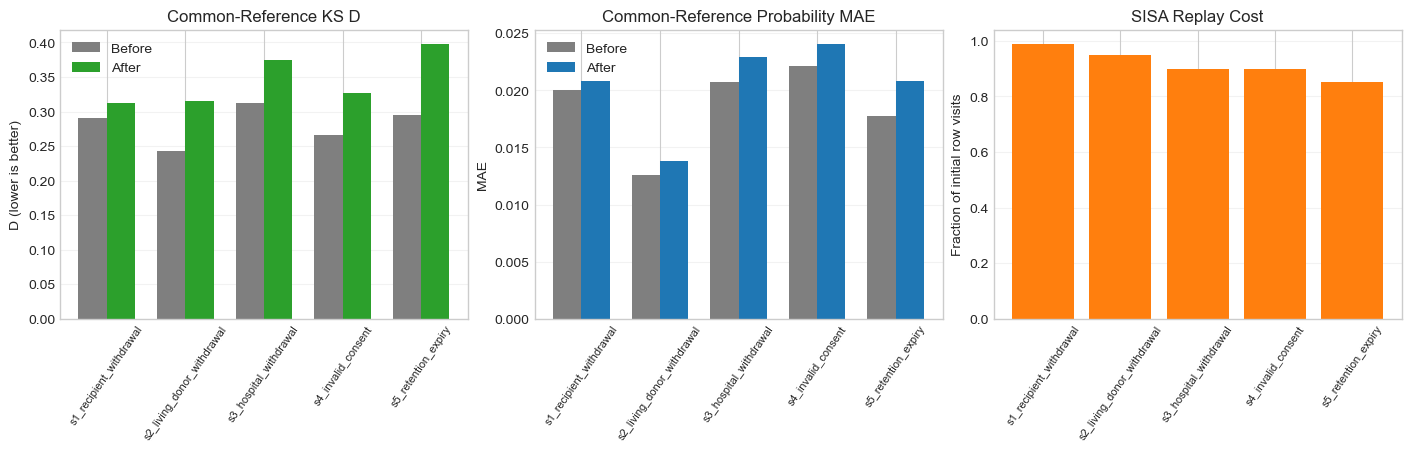

In [31]:
comparison_figure,axes=plt.subplots(1,3,figsize=(14,4.4),constrained_layout=True); x=np.arange(len(SCENARIO_NAMES)); width=.36
axes[0].bar(x-width/2,common_forget_quality["ks_d_before"],width,label="Before",color="#7f7f7f")
axes[0].bar(x+width/2,common_forget_quality["ks_d_after"],width,label="After",color="#2ca02c")
axes[0].set(title="Common-Reference KS D",ylabel="D (lower is better)",xticks=x,xticklabels=SCENARIO_NAMES); axes[0].legend()
axes[1].bar(x-width/2,common_forget_quality["probability_mae_before"],width,label="Before",color="#7f7f7f")
axes[1].bar(x+width/2,common_forget_quality["probability_mae_after"],width,label="After",color="#1f77b4")
axes[1].set(title="Common-Reference Probability MAE",ylabel="MAE",xticks=x,xticklabels=SCENARIO_NAMES); axes[1].legend()
axes[2].bar(runtime_metrics["scenario"],runtime_metrics["replay_fraction"],color="#ff7f0e")
axes[2].set(title="SISA Replay Cost",ylabel="Fraction of initial row visits")
for axis in axes: axis.tick_params(axis="x",rotation=55,labelsize=8); axis.grid(axis="y",alpha=.25)
display(comparison_figure); plt.close(comparison_figure)

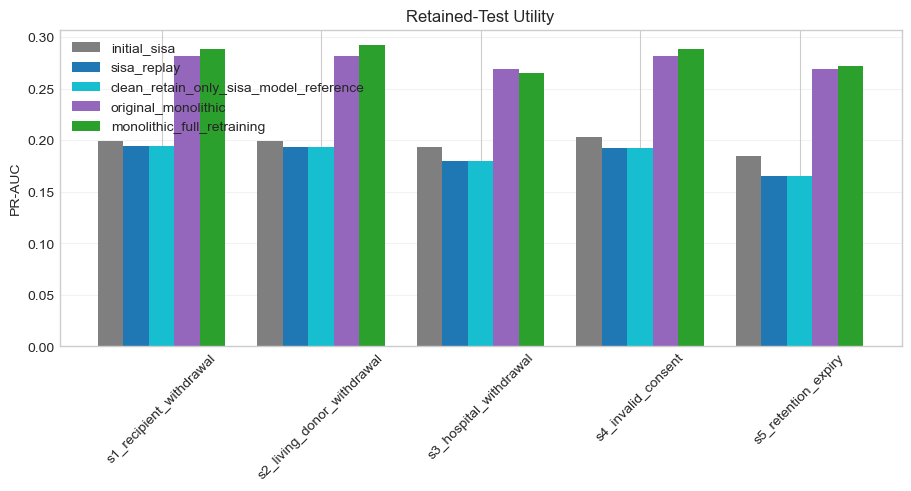

In [32]:
utility_figure,axis=plt.subplots(figsize=(9,4.8),constrained_layout=True)
models=["initial_sisa","sisa_replay","clean_retain_only_sisa_model_reference",
        "original_monolithic","monolithic_full_retraining"]
colours=["#7f7f7f","#1f77b4","#17becf","#9467bd","#2ca02c"]
x=np.arange(len(SCENARIO_NAMES)); width=.16
for offset,(model,colour) in enumerate(zip(models,colours)):
    rows=common_utility.query("model == @model")
    axis.bar(x+(offset-2)*width,rows["pr_auc"],width,label=model,color=colour)
axis.set(title="Retained-Test Utility",ylabel="PR-AUC",xticks=x,xticklabels=SCENARIO_NAMES)
axis.tick_params(axis="x",rotation=45); axis.legend(); axis.grid(axis="y",alpha=.25)
display(utility_figure); plt.close(utility_figure)

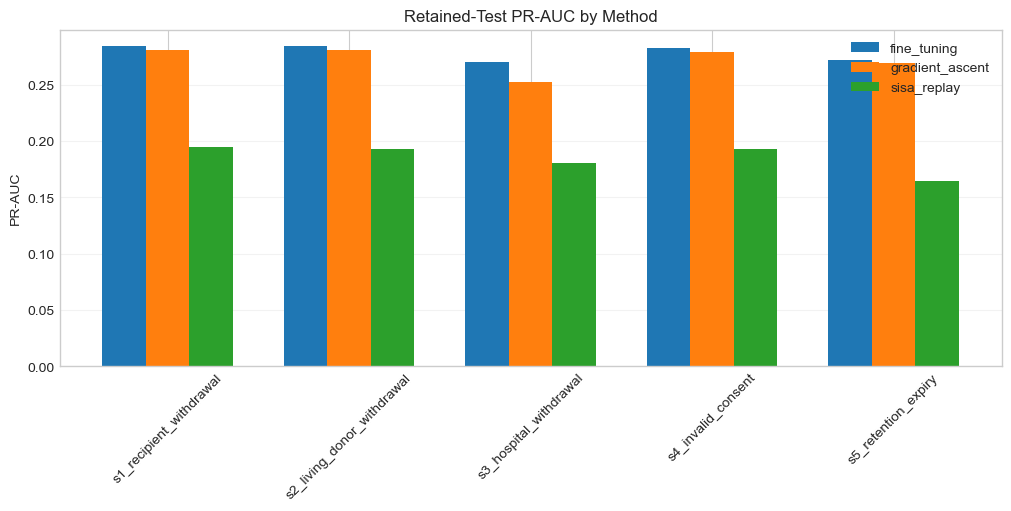

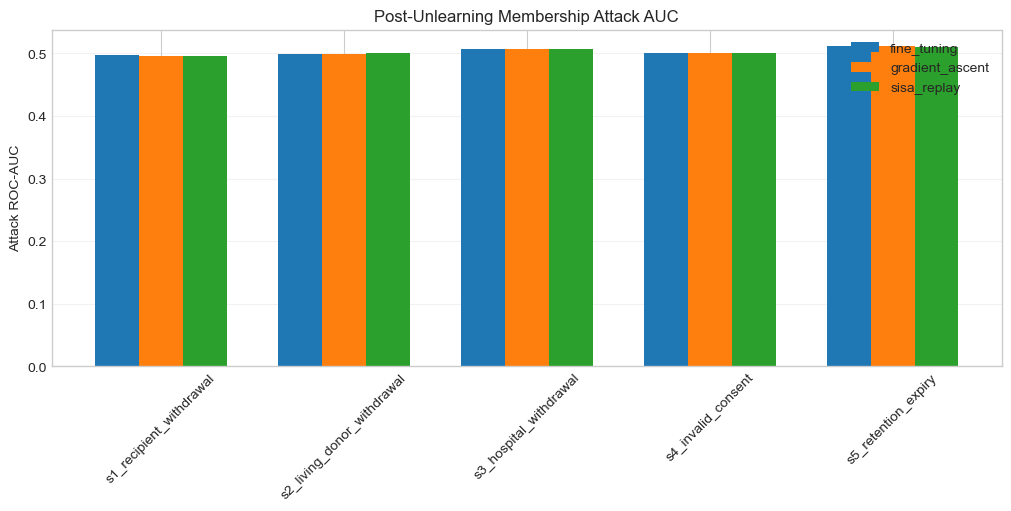

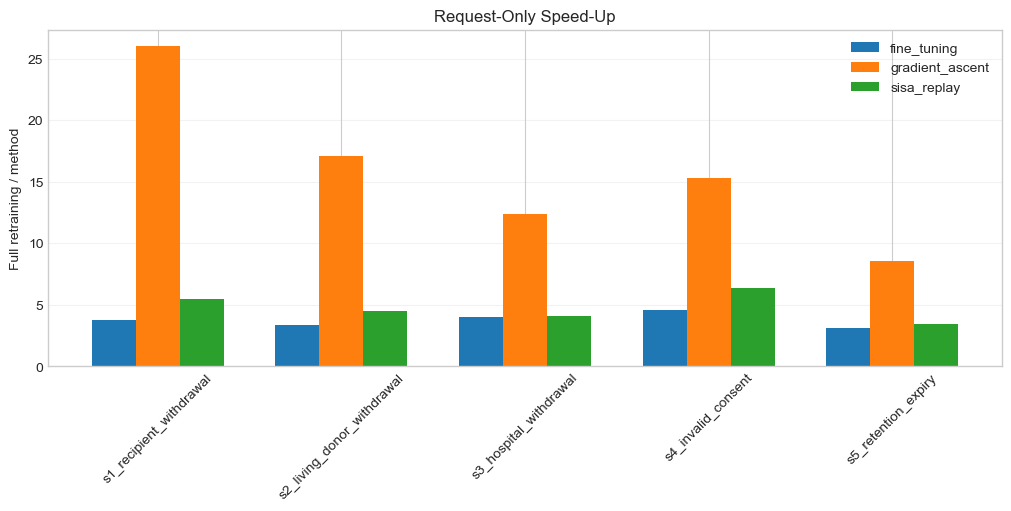

In [33]:
method_order=["fine_tuning","gradient_ascent","sisa_replay"]
method_colours={"fine_tuning":"#1f77b4","gradient_ascent":"#ff7f0e","sisa_replay":"#2ca02c"}
def grouped_bar(metric,title,ylabel):
    figure,axis=plt.subplots(figsize=(10,5),constrained_layout=True); x=np.arange(len(SCENARIO_NAMES)); width=.24
    for position,method in enumerate(method_order):
        rows=consolidated_comparison.query("method == @method").set_index("scenario").loc[SCENARIO_NAMES]
        axis.bar(x+(position-1)*width,rows[metric],width,label=method,color=method_colours[method])
    axis.set(title=title,ylabel=ylabel,xticks=x,xticklabels=SCENARIO_NAMES)
    axis.tick_params(axis="x",rotation=45); axis.legend(); axis.grid(axis="y",alpha=.25)
    display(figure); plt.close(figure); return figure

cross_pr_figure=grouped_bar("retained_test_pr_auc","Retained-Test PR-AUC by Method","PR-AUC")
cross_membership_figure=grouped_bar("membership_attack_auc_after","Post-Unlearning Membership Attack AUC","Attack ROC-AUC")
cross_speed_figure=grouped_bar("speed_up","Request-Only Speed-Up","Full retraining / method")

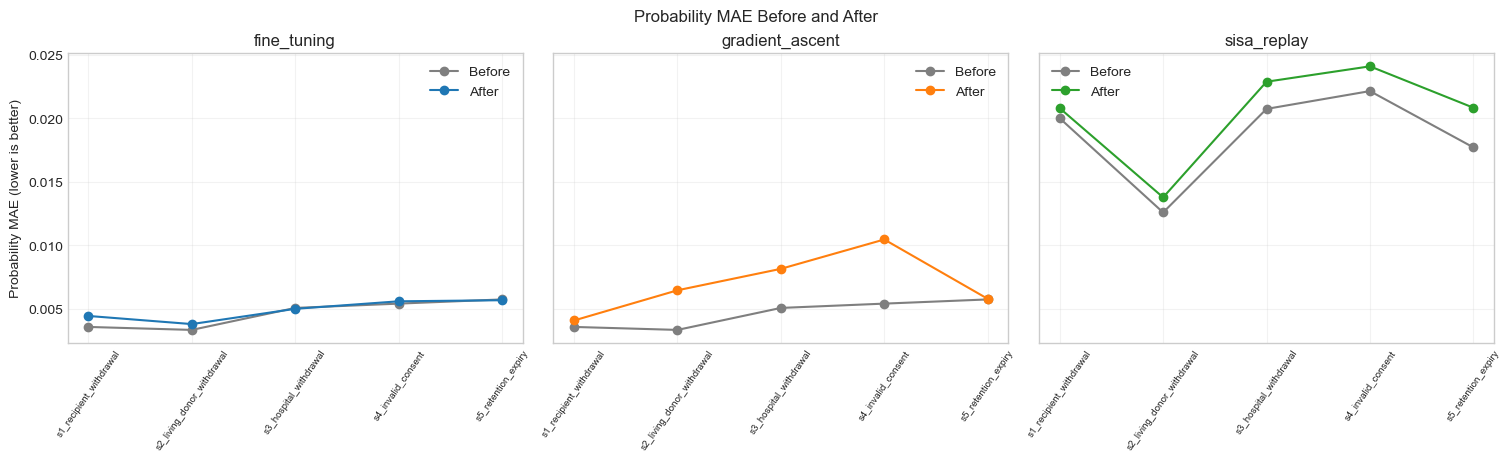

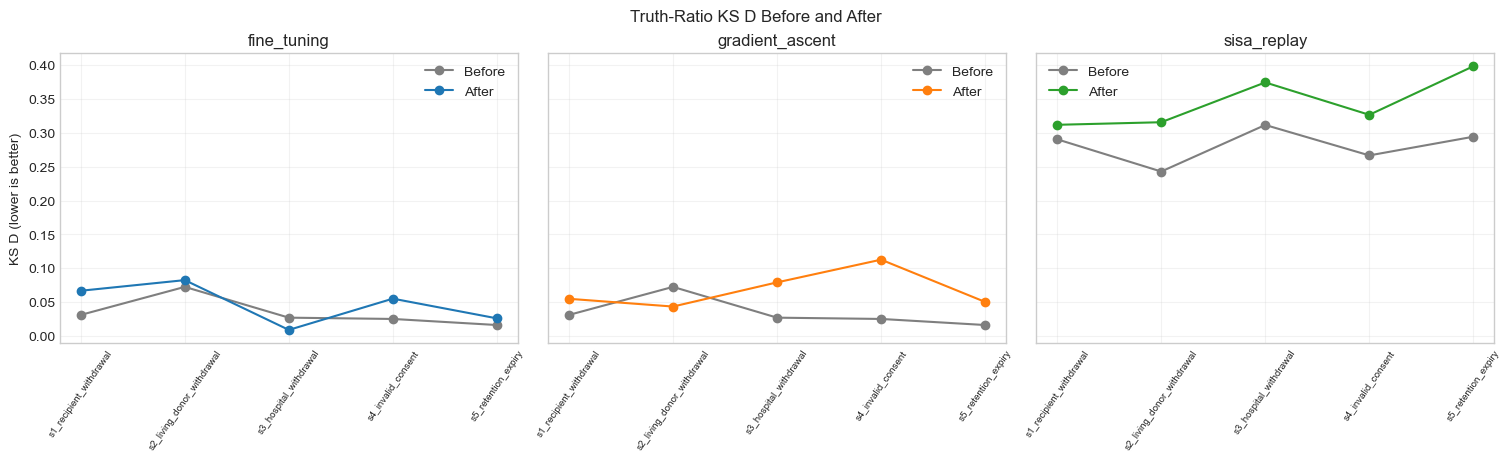

In [34]:
def before_after_plot(before,after,title,ylabel):
    figure,axes=plt.subplots(1,3,figsize=(15,4.5),sharey=True,constrained_layout=True)
    x=np.arange(len(SCENARIO_NAMES))
    for axis,method in zip(axes,method_order):
        rows=consolidated_comparison.query("method == @method").set_index("scenario").loc[SCENARIO_NAMES]
        axis.plot(x,rows[before],marker="o",label="Before",color="#7f7f7f")
        axis.plot(x,rows[after],marker="o",label="After",color=method_colours[method])
        axis.set(title=method,xticks=x,xticklabels=SCENARIO_NAMES); axis.tick_params(axis="x",rotation=55,labelsize=7)
        axis.grid(alpha=.25); axis.legend()
    axes[0].set_ylabel(ylabel); figure.suptitle(title); display(figure); plt.close(figure); return figure

cross_mae_figure=before_after_plot("probability_mae_before","probability_mae_after",
    "Probability MAE Before and After","Probability MAE (lower is better)")
cross_ks_figure=before_after_plot("ks_d_before","ks_d_after",
    "Truth-Ratio KS D Before and After","KS D (lower is better)")

## 15. Centralised Saving

Initial checkpoints, replay ensembles, clean references, tables and figures are saved after computation, then hashed for auditability.

In [35]:
TABLES={"assignment":(assignment,OUTPUT_DIRS["tables"]/"shard_slice_assignment.csv"),
        "initial_history":(initial_history,OUTPUT_DIRS["histories"]/"initial_training_history.csv"),
        "utility":(common_utility,OUTPUT_DIRS["metrics"]/"common_reference_utility.csv"),
        "common_forget":(common_forget_quality,OUTPUT_DIRS["metrics"]/"common_reference_forget_quality.csv"),
        "class_conditional_forget":(class_conditional_forget_metrics,OUTPUT_DIRS["metrics"]/"class_conditional_forget_metrics.csv"),
        "membership_attack":(membership_attack,OUTPUT_DIRS["metrics"]/"membership_attack_metrics.csv"),
        "mae_bootstrap":(mae_bootstrap_intervals,OUTPUT_DIRS["metrics"]/"probability_mae_bootstrap_intervals.csv"),
        "sisa_threshold_sweep":(sisa_threshold_sweep,OUTPUT_DIRS["tables"]/"sisa_threshold_validation_sweep.csv"),
        "matched":(method_matched,OUTPUT_DIRS["metrics"]/"method_matched_verification.csv"),
        "runtime":(runtime_metrics,OUTPUT_DIRS["tables"]/"runtime_metrics.csv")}
TABLES["consolidated_comparison"]=(consolidated_comparison,OUTPUT_DIRS["tables"]/"consolidated_cross_method_comparison.csv")
for frame,path in TABLES.values(): frame.to_csv(path,index=False)
for name,run in replay_runs.items(): run["history"].to_csv(OUTPUT_DIRS["histories"]/f"{name}_replay_history.csv",index=False)

In [36]:
# Persist every initial stage checkpoint with explicit after-slice semantics.
for shard_id,stages in initial_checkpoints.items():
    shard_dir=OUTPUT_DIRS["checkpoints"]/f"shard_{shard_id}"; shard_dir.mkdir(parents=True,exist_ok=True)
    for stage,state in stages.items(): torch.save({"state_dict":state,"shard":shard_id,"completed_slices":stage},shard_dir/f"after_slice_{stage}.pt")

MODEL_PATHS={}; CLEAN_MODEL_PATHS={}
for name in SCENARIO_NAMES:
    scenario_dir=MODEL_ROOT/name; scenario_dir.mkdir(parents=True,exist_ok=True)
    MODEL_PATHS[name]=[]; CLEAN_MODEL_PATHS[name]=[]
    for shard_id in range(SHARD_COUNT):
        path=scenario_dir/f"replayed_shard_{shard_id}.pt"; MODEL_PATHS[name].append(path)
        torch.save({"state_dict":clone_state(replay_runs[name]["models"][shard_id]),"input_dim":baseline_checkpoint["input_dim"],
                    "scenario":name,"shard":shard_id,"method":"sisa_replay","threshold":SISA_THRESHOLD,
                    "forget_index_hash":index_hash(forget_indices[name])},path)
        clean_path=scenario_dir/f"clean_reference_shard_{shard_id}.pt"; CLEAN_MODEL_PATHS[name].append(clean_path)
        torch.save({"state_dict":clone_state(clean_runs[name]["models"][shard_id]),"input_dim":baseline_checkpoint["input_dim"],
                    "scenario":name,"shard":shard_id,"method":"clean_retain_only_sisa_model_reference",
                    "threshold":SISA_THRESHOLD,"forget_index_hash":index_hash(forget_indices[name])},clean_path)

checkpoint_files=list(OUTPUT_DIRS["checkpoints"].glob("**/*.pt"))
checkpoint_storage_bytes=sum(path.stat().st_size for path in checkpoint_files)
storage_summary=pd.DataFrame([{"saved_checkpoints":len(checkpoint_files),
    "checkpoint_storage_bytes":checkpoint_storage_bytes,
    "checkpoint_storage_megabytes":checkpoint_storage_bytes/1024**2}])
storage_path=OUTPUT_DIRS["tables"]/"checkpoint_storage.csv"
storage_summary.to_csv(storage_path,index=False); TABLES["storage"]=(storage_summary,storage_path)
display(storage_summary.style.hide(axis="index").format({"checkpoint_storage_megabytes":"{:.3f}"}))

saved_checkpoints,checkpoint_storage_bytes,checkpoint_storage_megabytes
30,236400,0.225


In [37]:
FIGURES={"histories":OUTPUT_DIRS["figures"]/"initial_sisa_histories.png",
         "comparison":OUTPUT_DIRS["figures"]/"forgetting_and_replay_cost.png",
         "utility":OUTPUT_DIRS["figures"]/"retained_utility.png",
         "cross_method_pr_auc":OUTPUT_DIRS["figures"]/"cross_method_retained_pr_auc.png",
         "cross_method_probability_mae":OUTPUT_DIRS["figures"]/"cross_method_probability_mae.png",
         "cross_method_ks_d":OUTPUT_DIRS["figures"]/"cross_method_ks_d.png",
         "cross_method_membership":OUTPUT_DIRS["figures"]/"cross_method_membership_attack.png",
         "cross_method_speed_up":OUTPUT_DIRS["figures"]/"cross_method_runtime_speedup.png"}
history_figure.savefig(FIGURES["histories"],dpi=300,bbox_inches="tight")
comparison_figure.savefig(FIGURES["comparison"],dpi=300,bbox_inches="tight")
utility_figure.savefig(FIGURES["utility"],dpi=300,bbox_inches="tight")
cross_pr_figure.savefig(FIGURES["cross_method_pr_auc"],dpi=300,bbox_inches="tight")
cross_mae_figure.savefig(FIGURES["cross_method_probability_mae"],dpi=300,bbox_inches="tight")
cross_ks_figure.savefig(FIGURES["cross_method_ks_d"],dpi=300,bbox_inches="tight")
cross_membership_figure.savefig(FIGURES["cross_method_membership"],dpi=300,bbox_inches="tight")
cross_speed_figure.savefig(FIGURES["cross_method_speed_up"],dpi=300,bbox_inches="tight")

manifest={"method":"SISA","configuration":{"shards":SHARD_COUNT,"slices":SLICE_COUNT,"epochs_per_stage":EPOCHS_PER_STAGE,
            "seed":RANDOM_SEED,"optimizer_semantics":"fresh Adam optimiser for each slice",
            "checkpoint_semantics":"after_slice_k inherits prior weights and has just trained on slice k only; slice_0 is initialization"},
          "dataset_path":str(DATA_PATH.relative_to(CODE_ROOT)),"dataset_hash":sha256(DATA_PATH),
          "dataset_description":"Entirely synthetic longitudinal kidney-transplant follow-up assessments.",
          "target":TARGET_COLUMN,"feature_list":FEATURE_COLUMNS,"excluded_audit_fields":EXCLUDED_COLUMNS,
          "split_strategy":baseline_manifest["split_strategy"],"group_key":"recipient_id","seeds":[RANDOM_SEED],
          "monolithic_threshold":THRESHOLD,"sisa_threshold":SISA_THRESHOLD,
          "sisa_threshold_selection_rule":SISA_THRESHOLD_REASON,"loss_choice":"BCEWithLogitsLoss",
          "deletion_configuration":SCENARIOS,"index_hashes":full_manifest["index_hashes"],
          "preprocessing_policy":"frozen original pre-deletion preprocessor shared by replay and clean model-only SISA reference",
          "bootstrap_configuration":{"unit":"recipient_id","seed":BOOTSTRAP_SEED,"repetitions":BOOTSTRAP_REPETITIONS},
          "membership_attack_configuration":{"score":"negative_per_record_bce","seed":MEMBERSHIP_SEED,
            "matched_sampling_repetitions":MEMBERSHIP_REPETITIONS,"matching":["target","days_since_transplant","donor_type"]},
          "runtime_environment":{"python":platform.python_version(),"numpy":np.__version__,"pandas":pd.__version__,
            "scipy":scipy.__version__,"scikit_learn":sklearn.__version__,"pytorch":torch.__version__,"device":str(DEVICE)},
          "artifact_hashes":{}}
MANIFEST_PATH=OUTPUT_DIRS["configuration"]/"sisa_manifest.json"

In [38]:
artifact_paths=[*[path for _,path in TABLES.values()],*FIGURES.values(),
                *[path for paths in MODEL_PATHS.values() for path in paths],
                *[path for paths in CLEAN_MODEL_PATHS.values() for path in paths]]
artifact_paths+=list(OUTPUT_DIRS["histories"].glob("*.csv"))+list(OUTPUT_DIRS["checkpoints"].glob("**/*.pt"))
# Hash all model, checkpoint, table and figure outputs for the final reload audit.
manifest["artifact_hashes"]={str(path.relative_to(CODE_ROOT)):sha256(path) for path in artifact_paths}
MANIFEST_PATH.write_text(json.dumps(manifest,indent=2))
print(f"Saved {len(artifact_paths)} SISA artifacts and manifest.")

Saved 106 SISA artifacts and manifest.


## 16. Reload and Verification

Reloading verifies checkpoint semantics, predictions, parameter persistence, numeric tables, and artifact hashes.

In [39]:
for frame,path in TABLES.values():
    saved=pd.read_csv(path); assert saved.columns.tolist()==frame.columns.tolist() and len(saved)==len(frame)
    for column in frame.select_dtypes(include=np.number): assert np.allclose(saved[column],frame[column],equal_nan=True)
for name,paths in MODEL_PATHS.items():
    for shard_id,path in enumerate(paths):
        checkpoint=torch.load(path,map_location="cpu",weights_only=False); model=KidneyMLP(checkpoint["input_dim"])
        model.load_state_dict(checkpoint["state_dict"]); model=model.to(DEVICE)
        sample=features.loc[test_indices].iloc[:16]
        assert np.allclose(predict_model(model,baseline_preprocessor,sample),
                           predict_model(replay_runs[name]["models"][shard_id],baseline_preprocessor,sample),rtol=1e-6,atol=1e-7)
assert json.loads(MANIFEST_PATH.read_text())==manifest
assert all(sha256(CODE_ROOT/path)==digest for path,digest in manifest["artifact_hashes"].items())
print("SISA checkpoints, ensembles, predictions, tables, figures and manifest reloaded successfully.")

SISA checkpoints, ensembles, predictions, tables, figures and manifest reloaded successfully.


## 17. Final Discussion

In [40]:
all_shards = runtime_metrics["affected_shards"].eq(SHARD_COUNT).sum()
slice_one = runtime_metrics["earliest_affected_slice"].eq(1).sum()
labels = "; ".join(f"{row.scenario}: {row.result_label}" for row in common_forget_quality.itertuples())
lifecycle_not_faster = runtime_metrics["total_lifecycle_speed_up"].le(1).sum()
display(Markdown(
    f"- **Organisation:** 7,000 complete recipient episodes were assigned to {SHARD_COUNT} isolated shards and {SLICE_COUNT} ordered slices.\n"
    "- **Common reference:** monolithic full retraining supports cross-method behavioural comparison.\n"
    f"- **SISA threshold:** the initial ensemble selected {SISA_THRESHOLD:.2f} from validation using the recall-at-least-0.60 rule.\n"
    "- **Method-matched verification:** replay predictions and parameters equal the clean retain-only SISA model reference within deterministic tolerance.\n"
    f"- **Common-reference outcomes:** {labels}.\n"
    f"- **Efficiency limitation:** {all_shards} requests affected all shards and {slice_one} reached slice 1; {lifecycle_not_faster} lifecycle comparisons were not faster than full retraining. The chosen batch requests receive little isolation benefit.\n"
    "- **Preprocessing limitation:** exact model replay equality does not remove influence from the frozen pre-deletion preprocessing statistics.\n"
    "- **Limitations:** synthetic data, fixed architecture and shard design, behavioural evidence only, and no certified, regulatory or clinical guarantee."
))

- **Organisation:** 7,000 complete recipient episodes were assigned to 5 isolated shards and 5 ordered slices.
- **Common reference:** monolithic full retraining supports cross-method behavioural comparison.
- **SISA threshold:** the initial ensemble selected 0.05 from validation using the recall-at-least-0.60 rule.
- **Method-matched verification:** replay predictions and parameters equal the clean retain-only SISA model reference within deterministic tolerance.
- **Common-reference outcomes:** s1_recipient_withdrawal: worsened; s2_living_donor_withdrawal: worsened; s3_hospital_withdrawal: worsened; s4_invalid_consent: worsened; s5_retention_expiry: worsened.
- **Efficiency limitation:** 5 requests affected all shards and 5 reached slice 1; 0 lifecycle comparisons were not faster than full retraining. The chosen batch requests receive little isolation benefit.
- **Preprocessing limitation:** exact model replay equality does not remove influence from the frozen pre-deletion preprocessing statistics.
- **Limitations:** synthetic data, fixed architecture and shard design, behavioural evidence only, and no certified, regulatory or clinical guarantee.